In [ ]:
# ..... get paralog substituion events including ancient paralogs ..... #
# across all primate clusters x mouse subclasses
# just the no. of shared and paralog markers

In [2]:
library(data.table)
library(dplyr)
library(ggplot2)

In [3]:
# get no. of paralogs between two vectors
get_paralog_count <- function(vec1, vec2, pmat){
    mat1 = data.frame(g1 = rep(vec1, each = length(vec2)), 
                      g2 = rep(vec2, length(vec1)), paralog = NA)
    glist = paste0(mat1[,1], '_', mat1[,2])
    mat1$paralog = !is.na(match(glist, pmat))
    temp = mat1 %>% group_by(g1) %>% summarise(n = sum(paralog))
    return(temp)
}

In [4]:
# get list of paralogs 
tab1 = read.delim('/vault/suresh/consensus_interneuron_taxonomy/homologs/human_paralogs.txt', sep = '\t')
tab1 <- tab1[(tab1[,1]!='' & tab1[,2]!='' & tab1[,4]!='' & tab1[,4]!='gene_split'),]
tab1 <- tab1[!duplicated(tab1),]
colnames(tab1)[1:2] = c('sp1_gene', 'sp2_gene')

# human - NHP
paralog_df1 = paste0(unlist(tab1$sp1_gene), '_', unlist(tab1$sp2_gene))

# NHP - human
paralog_df2 = paralog_df1

head(paralog_df1)

[1] "MT-ND2_MT-ND4" "MT-ND2_MT-ND5" "MT-ND4_MT-ND5" "MT-ND4_MT-ND2"
[5] "MT-ND5_MT-ND4" "MT-ND5_MT-ND2"

In [29]:
# get marker lists
sp1 = 'tree_shrew'
sp1_ctype = 'cluster'
sp2 = 'marmoset'
currstudy = 'sestan'

if(sp1 == 'tree_shrew' & sp1_ctype=='subclass'){
    tab2 = fread('tree_shrew_ortho_subclass_markers.csv.gz')
    tab2 <- tab2[which(tab2$cell_type!='other'),]   # remove other subclass
    
}else if(sp1 == 'tree_shrew' & sp1_ctype!='subclass'){
    tab2 = fread('tree_shrew_de_novo_markers.csv.gz')
    tab2 <- tab2[which(tab2$cell_type!='16'),]   # remove other cluster
    
}else{
    tab2 = fread(paste0(sp1, '_subclass_metaMarkers.csv.gz'))
}
ctypes2 = unique(tab2$cell_type)
tab2[1:2,]

tab3 = fread(paste0(currstudy, '_', sp2, '_de_novo_cluster_markers.csv.gz'))
ctypes3 = unique(tab3$cell_type)
tab3[1:2,]

group,cell_type,gene,fold_change,auroc,log_fdr,population_size,population_fraction,average_expression,se_expression,detection_rate,fold_change_detection,precision,recall
<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,0,GALNTL6,3.558470,0.9075404,-428.4980,493,0.1150794,17789.79,350.1192,0.9898580,1.148100,0.1299255,0.9898580
all,0,LRP1B,2.714011,0.8841408,-380.6524,493,0.1150794,11327.38,237.0338,0.9959432,1.079588,0.1231194,0.9959432


group,cell_type,gene,fold_change,auroc,log_fdr,population_size,population_fraction,average_expression,se_expression,detection_rate,fold_change_detection,precision,recall
<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,0,KAZN,2.319694,0.9005982,-2185.326,2495,0.08739667,5289.255,33.78873,0.9991984,1.023573,0.08927484,0.9991984
all,0,FGF12,1.934287,0.8758221,-1923.478,2495,0.08739667,3393.967,22.20508,1.0000000,1.008625,0.08808473,1.0000000


In [30]:
# get top 100 markers
tab2$rank = rep(1:(dim(tab2)[1]/length(ctypes2)), length(ctypes2))
top_markers1 = tab2[(tab2$rank<=100),]
tab3$rank = rep(1:(dim(tab3)[1]/length(ctypes3)), length(ctypes3))
top_markers2 = tab3[(tab3$rank<=100),]

In [31]:
combos = rbind(rep(ctypes2, each = length(ctypes3)), rep(ctypes3, length(ctypes2)))
dim(combos)
combos[1:2,1:4]

[1]   2 390

0,0,0,0
0,1,10,11


In [32]:
newdf = data.frame(cluster1 = combos[1,], cluster2 = combos[2,],
                  shared = NA, paralog1 = NA, paralog2 = NA)
pb = txtProgressBar(min = 0, max = dim(combos)[2], initial = 0)

for(ii in 1:dim(combos)[2]){ 
    ctype1 = combos[1,ii]
    ctype2 = combos[2,ii]
    m1 = top_markers1$gene[top_markers1$cell_type==ctype1]
    m2 = top_markers2$gene[top_markers2$cell_type==ctype2]
    
    temp = intersect(m1, m2)
    
    if(length(temp)){
        newdf$shared[ii] = length(temp)
        rem_genes1 = setdiff(m1, temp)
        rem_genes2 = setdiff(m2, temp)
    }else{
        rem_genes1 = m1
        rem_genes2 = m2
    }
    
    if(length(rem_genes1)){
        list1 = get_paralog_count(rem_genes1, m2, paralog_df1)
        newdf$paralog1[ii] = sum(list1[,2]>0)   # genes in cluster 1 are paralogs of markers in cluster 2; avoid double-counting
    }
    if(length(rem_genes2)){
        list2 = get_paralog_count(rem_genes2, m1, paralog_df2)
        newdf$paralog2[ii] = sum(list2[,2]>0)
    }
    
    setTxtProgressBar(pb, ii)
}

newdf$paralogs = rowMeans(newdf[,4:5], na.rm = T)
newdf[1:5,]

# save
path_to_save = paste0('/vault/suresh/consensus_interneuron_taxonomy/', currstudy, '/')

if(sp1 == 'tree_shrew' & sp1_ctype=='subclass'){
    savefile = paste0(path_to_save, sp1, '_subclass_', sp2, '_', currstudy, '_marker_paralogs_biomart.csv')
}else if(sp1 == 'tree_shrew' & sp1_ctype!='subclass'){
    savefile = paste0(path_to_save, sp1, '_cluster_', sp2, '_', currstudy, '_marker_paralogs_biomart.csv')
}else{
    savefile = paste0(path_to_save, sp1, '_', sp2, '_', currstudy, '_marker_paralogs_biomart.csv')
}
    
write.table(newdf, file = savefile, sep = ',', row.names = F, col.names = T, quote = F)

,cluster1,cluster2,shared,paralog1,paralog2,paralogs
,<int>,<int>,<int>,<int>,<int>,<dbl>
1,0,0,8,20,17,18.5
2,0,1,10,17,18,17.5
3,0,10,25,19,17,18.0
4,0,11,4,20,15,17.5
5,0,12,30,15,15,15.0


In [90]:
# ancestral Sncg - 17 in Sestan, 20 in Caglayan
v1 = tab2$gene[tab2$cell_type=='Vip'][1:200]
v2 = tab2$gene[tab2$cell_type=='Sncg'][1:200]
v3 = tab3$gene[tab3$cell_type=='17'][1:200]

# Vip and anc-Sncg but not Sncg
setdiff(intersect(v1, v3), v2)

# Sncg and anc-Sncg but not Vip
setdiff(intersect(v2, v3), v1)

[1] "VIP"     "KCNT2"   "IGF1"    "PROX1"   "SALL1"   "SDK1"    "DACH2"  
 [8] "KCNJ2"   "GRM7"    "SLC44A5" "EGFR"    "SYNPR"   "SLC1A2"

[1] "NR2F2"      "SDK2"       "NRG3"       "THSD7B"     "PIK3R1"    
 [6] "BMPER"      "PCDH18"     "NFIB"       "FAT4"       "CHSY3"     
[11] "PLXDC2"     "ADCY2"      "NPAS1"      "CSGALNACT1" "ZEB1"      
[16] "LINGO2"     "GRIK2"      "POU2F1"     "ARHGAP18"   "FBN2"      
[21] "STARD13"    "DOCK10"     "ZNF804B"    "NRXN1"      "PDE4D"

Warning message in cor.test.default(newdf$shared, newdf$paralogs, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  newdf$shared and newdf$paralogs
S = 2387682, p-value = 0.07131
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.1181192 


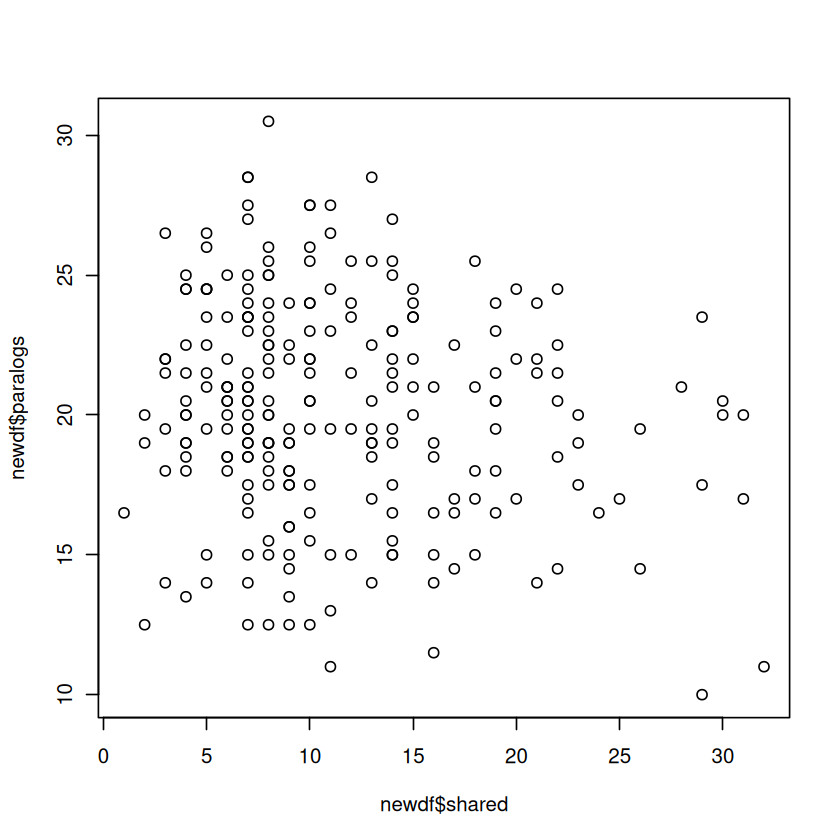

In [129]:
plot(newdf$shared, newdf$paralogs)
cor.test(newdf$shared, newdf$paralogs, method = 'spearman')